# Data Preparation & Initialization

### Set Gobal Seed

In [41]:
Seed = 1

### Import Data

In [42]:
import pandas as pd

df = pd.read_csv("packet-data/normalized_original_data.csv")

df.head()

,time_since_previously_displayed_frame,port_class_dst,l4_tcp,l4_udp,ttl,eth_size,tcp_window_size,payload_entropy,handshake_cipher_suites_length,handshake_ciphersuites,...,highest_layer_STUN,highest_layer_TCP,highest_layer_TLS,highest_layer_TPLINK-SMARTHOME,highest_layer_UDP,highest_layer_UDPENCAP,highest_layer_XML,highest_layer__WS.MALFORMED,id,label
0,0.824115,1.0,0.0,0.0,1.041916,-0.048780,-0.331699,-0.795316,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,benign
1,0.008429,-1.0,0.0,0.0,0.000000,8.780488,0.531342,0.216408,0.0,0.0,...,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,2,benign
2,0.216425,1.0,0.0,0.0,-0.053892,-0.048780,0.073130,-0.795316,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,benign
3,-0.148788,-1.0,0.0,0.0,0.000000,8.780488,0.531342,0.216590,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,benign
4,0.746796,1.0,0.0,0.0,1.035928,0.237805,-0.333876,0.146365,0.0,0.0,...,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,5,benign


### Drop Variables Not Used
- Drop "id" column

In [43]:
# ID is an identifier, not a behavioral feature.
df = df.drop(columns=["id"], errors="ignore")

df.head()

,time_since_previously_displayed_frame,port_class_dst,l4_tcp,l4_udp,ttl,eth_size,tcp_window_size,payload_entropy,handshake_cipher_suites_length,handshake_ciphersuites,...,highest_layer_STP,highest_layer_STUN,highest_layer_TCP,highest_layer_TLS,highest_layer_TPLINK-SMARTHOME,highest_layer_UDP,highest_layer_UDPENCAP,highest_layer_XML,highest_layer__WS.MALFORMED,label
0,0.824115,1.0,0.0,0.0,1.041916,-0.048780,-0.331699,-0.795316,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign
1,0.008429,-1.0,0.0,0.0,0.000000,8.780488,0.531342,0.216408,0.0,0.0,...,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,benign
2,0.216425,1.0,0.0,0.0,-0.053892,-0.048780,0.073130,-0.795316,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign
3,-0.148788,-1.0,0.0,0.0,0.000000,8.780488,0.531342,0.216590,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign
4,0.746796,1.0,0.0,0.0,1.035928,0.237805,-0.333876,0.146365,0.0,0.0,...,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,benign


### Create Data Matrix and Label Vector

In [44]:
# Separate the original label from the feature columns.
X = df.drop(columns=["label"]).to_numpy()
y = df["label"].to_numpy()

print("Data matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Data matrix shape: (195940, 164)
Label vector shape: (195940,)


# K-means (high-recall alert generator)

### K-means Hyperparameters Tuning
- Hyperparameters:
    - K: number of clusters used to represent benign behaviour
    - Threshold_percentile: distance cutoff for classifying a sample as anomalous

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

k_values = [2, 4, 6, 8, 10, 15, 20]
threshold_percentiles = [90, 95, 97, 99]

# Train only on benign examples and reserve benign examples for evaluation.
X_benign = X[y == "benign"]
X_attack = X[y != "benign"]
y_attack = y[y != "benign"]
X_benign_train, X_benign_test = train_test_split(
    X_benign, test_size=0.2, random_state=Seed
)

# Fit preprocessing on benign training data only.
scaler = StandardScaler()
X_benign_train = scaler.fit_transform(X_benign_train)
X_benign_test = scaler.transform(X_benign_test)
X_attack = scaler.transform(X_attack)

X_evaluation = np.vstack([X_benign_test, X_attack])
y_evaluation = np.concatenate([
    np.full(X_benign_test.shape[0], "benign", dtype=object),
    y_attack,
])
true_attack = y_evaluation != "benign"

models = {}
thresholds = {}
inertias = []
kmeans_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=5,
        random_state=Seed,
    )
    model.fit(X_benign_train)

    # A sample is anomalous when its nearest-centroid distance exceeds
    # the chosen percentile of benign training distances.
    benign_train_distances = model.transform(X_benign_train).min(axis=1)
    evaluation_distances = model.transform(X_evaluation).min(axis=1)

    models[k] = model
    inertias.append(model.inertia_)

    for percentile in threshold_percentiles:
        threshold = np.percentile(benign_train_distances, percentile)
        predicted_attack = evaluation_distances > threshold

        precision = precision_score(true_attack, predicted_attack, zero_division=0)
        recall = recall_score(true_attack, predicted_attack, zero_division=0)
        f1 = f1_score(true_attack, predicted_attack, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(
            true_attack, predicted_attack, labels=[False, True]
        ).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        fnr = fn / (fn + tp) if (fn + tp) else 0.0

        thresholds[(k, percentile)] = threshold
        kmeans_results.append({
            "k": k,
            "threshold_percentile": percentile,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "fpr": fpr,
            "fnr": fnr,
        })

        print(
            f"k={k}, percentile={percentile}: Precision={precision:.4f}, "
            f"Recall={recall:.4f}, F1={f1:.4f}"
        )
        print("  Confusion matrix [[TP, FP], [FN, TN]]:")
        print("  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]")
        print(np.array([[tp, fp], [fn, tn]]))
        for attack in sorted(np.unique(y_attack)):
            attack_mask = y_evaluation == attack
            detection_rate = predicted_attack[attack_mask].mean()
            print(f"  {attack} detection rate: {detection_rate:.4f}")

kmeans_results_df = pd.DataFrame(kmeans_results)
display(
    kmeans_results_df.sort_values("fnr", ascending=True).reset_index(drop=True)
)

k=2, percentile=90: Precision=0.4398, Recall=0.5062, F1=0.4707
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 3007  3830]
 [ 2933 34170]]
  brute_force detection rate: 0.3342
  ddos detection rate: 0.8544
  dns_spoofing detection rate: 0.2753
  dos detection rate: 0.8939
  xss detection rate: 0.1734
k=2, percentile=95: Precision=0.5856, Recall=0.4532, F1=0.5110
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 2692  1905]
 [ 3248 36095]]
  brute_force detection rate: 0.3005
  ddos detection rate: 0.7887
  dns_spoofing detection rate: 0.1886
  dos detection rate: 0.8897
  xss detection rate: 0.0985
k=2, percentile=97: Precision=0.6770, Recall=0.3983, F1=0.5015
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 2366  1129]
 [ 3574 36871]]
  brute_force detection rate: 0.2264
  ddos detection rate: 0.

,k,threshold_percentile,precision,recall,f1,fpr,fnr
0,15,90,0.460695,0.551515,0.502030,0.100921,0.448485
1,20,90,0.458797,0.541751,0.496835,0.099895,0.458249
2,10,90,0.458512,0.541414,0.496526,0.099947,0.458586
3,6,90,0.453568,0.532828,0.490014,0.100342,0.467172
4,8,90,0.446845,0.525758,0.483100,0.101737,0.474242
5,4,90,0.442176,0.510438,0.473861,0.100658,0.489562
6,2,90,0.439813,0.506229,0.470690,0.100789,0.493771
7,15,95,0.595657,0.484848,0.534571,0.051447,0.515152
8,6,95,0.597815,0.478956,0.531825,0.050368,0.521044
9,20,95,0.591620,0.477778,0.528639,0.051553,0.522222


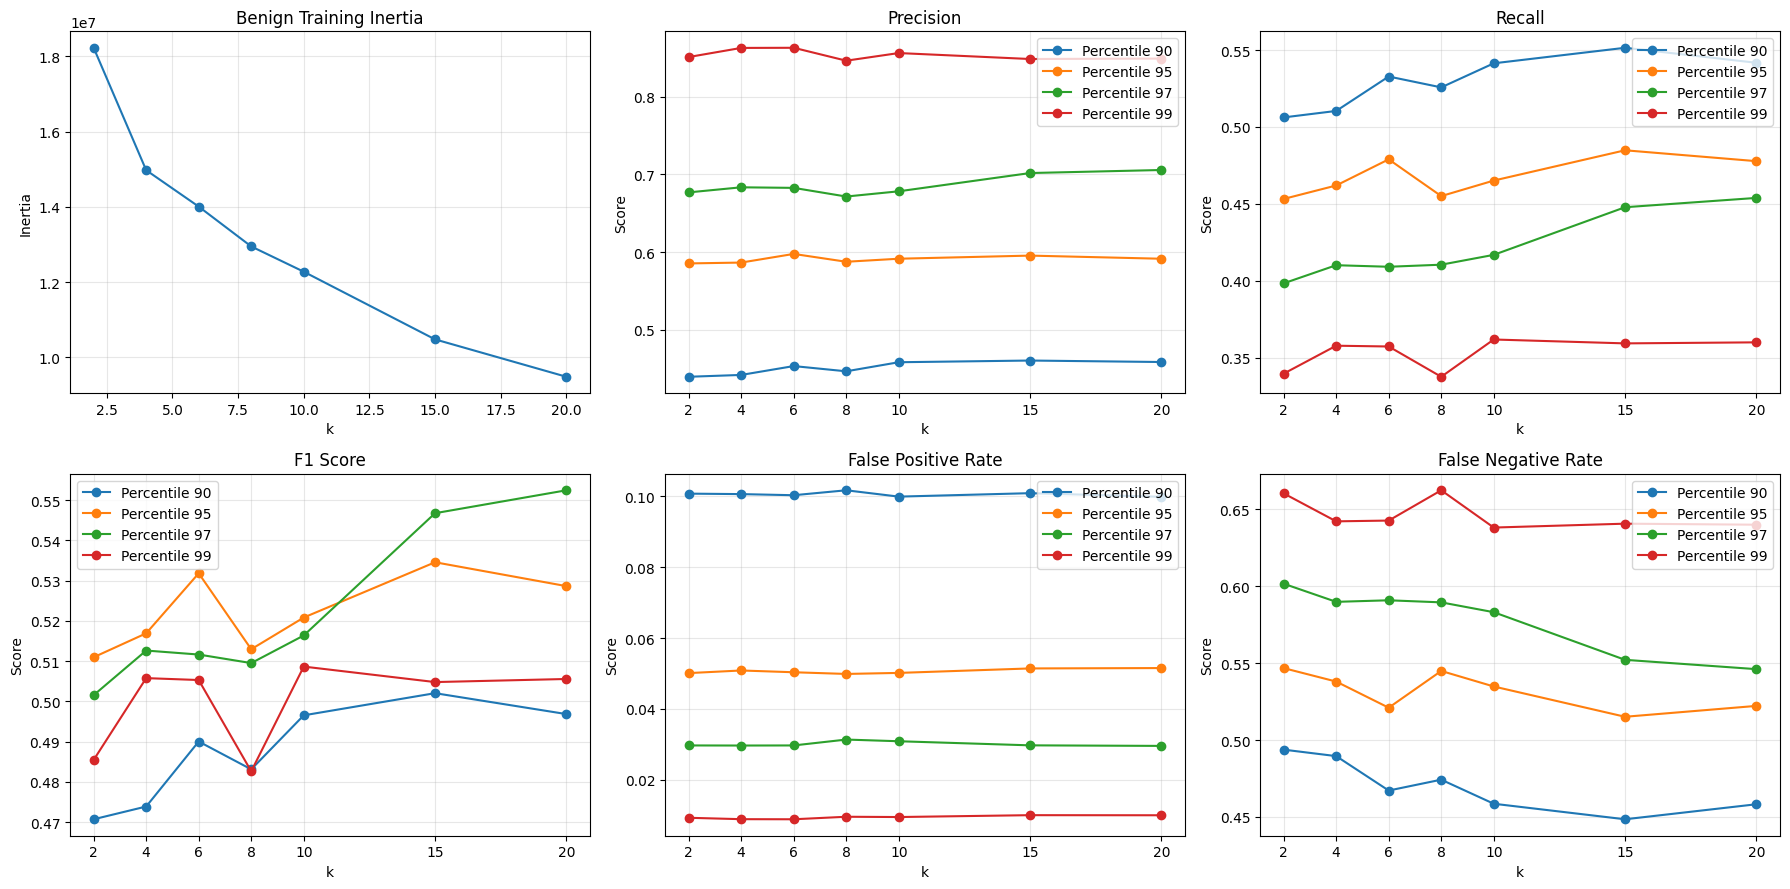

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

# Plot inertia to show how well the model fits the benign training data.
axes[0].plot(k_values, inertias, marker="o")
axes[0].set(title="Benign Training Inertia", xlabel="k", ylabel="Inertia")
axes[0].grid(alpha=0.3)

# Plot each metric for every threshold percentile.
for axis, metric, title in zip(
    axes[1:],
    ["precision", "recall", "f1", "fpr", "fnr"],
    ["Precision", "Recall", "F1 Score", "False Positive Rate", "False Negative Rate"],
):
    for percentile in threshold_percentiles:
        subset = kmeans_results_df[
            kmeans_results_df["threshold_percentile"] == percentile
        ].sort_values("k")
        axis.plot(
            subset["k"], subset[metric], marker="o", label=f"Percentile {percentile}"
        )
    axis.set(title=title, xlabel="k", ylabel="Score")
    axis.set_xticks(k_values)
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

# Autoencoders (high-recall alert generator)

### Autoencoders Hyperparameters Tuning

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

keras.utils.set_random_seed(Seed)

bottleneck_sizes = [2, 4, 8, 16, 32]
threshold_percentiles = [90, 95, 97, 99]

# Train the autoencoder only on benign data.
X_benign_ae = X[y == "benign"]
X_attack_ae = X[y != "benign"]
y_attack_ae = y[y != "benign"]
X_benign_train_ae, X_benign_test_ae = train_test_split(
    X_benign_ae, test_size=0.2, random_state=Seed
)

# Fit preprocessing only on benign training examples.
ae_scaler = StandardScaler()
X_benign_train_ae = ae_scaler.fit_transform(X_benign_train_ae).astype(np.float32)
X_benign_test_ae = ae_scaler.transform(X_benign_test_ae).astype(np.float32)
X_attack_ae = ae_scaler.transform(X_attack_ae).astype(np.float32)

X_evaluation_ae = np.vstack([X_benign_test_ae, X_attack_ae])
y_evaluation_ae = np.concatenate([
    np.full(X_benign_test_ae.shape[0], "benign", dtype=object),
    y_attack_ae,
])
true_attack_ae = y_evaluation_ae != "benign"

input_dim = X_benign_train_ae.shape[1]
autoencoder_models = {}
ae_results = []

for bottleneck_size in bottleneck_sizes:
    keras.backend.clear_session()
    keras.utils.set_random_seed(Seed)

    inputs = keras.Input(shape=(input_dim,))
    encoded = keras.layers.Dense(64, activation="relu")(inputs)
    bottleneck = keras.layers.Dense(
        bottleneck_size, activation="relu", name="bottleneck"
    )(encoded)
    decoded = keras.layers.Dense(64, activation="relu")(bottleneck)
    outputs = keras.layers.Dense(input_dim)(decoded)
    autoencoder = keras.Model(inputs, outputs, name=f"autoencoder_{bottleneck_size}")
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    history = autoencoder.fit(
        X_benign_train_ae,
        X_benign_train_ae,
        epochs=50,
        batch_size=512,
        validation_split=0.1,
        shuffle=True,
        callbacks=[early_stopping],
        verbose=0,
    )
    autoencoder_models[bottleneck_size] = autoencoder
    print(f"Bottleneck {bottleneck_size}: trained for {len(history.history['loss'])} epochs")

    train_reconstruction = autoencoder.predict(X_benign_train_ae, verbose=0)
    train_errors = np.mean(
        (X_benign_train_ae - train_reconstruction) ** 2, axis=1
    )
    evaluation_reconstruction = autoencoder.predict(X_evaluation_ae, verbose=0)
    evaluation_errors = np.mean(
        (X_evaluation_ae - evaluation_reconstruction) ** 2, axis=1
    )

    for percentile in threshold_percentiles:
        threshold = np.percentile(train_errors, percentile)
        predicted_attack = evaluation_errors > threshold

        precision = precision_score(
            true_attack_ae, predicted_attack, zero_division=0
        )
        f1 = f1_score(true_attack_ae, predicted_attack, zero_division=0)
        recall = recall_score(true_attack_ae, predicted_attack, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(
            true_attack_ae, predicted_attack, labels=[False, True]
        ).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        fnr = fn / (fn + tp) if (fn + tp) else 0.0

        result = {
            "bottleneck_size": bottleneck_size,
            "threshold_percentile": percentile,
            "threshold": threshold,
            "precision": precision,
            "f1": f1,
            "recall": recall,
            "fpr": fpr,
            "fnr": fnr,
        }
        ae_results.append(result)

        print(
            f"bottleneck={bottleneck_size}, percentile={percentile}: "
            f"Precision={precision:.4f}, Recall={recall:.4f}, "
            f"F1={f1:.4f}"
        )
        print("  Confusion matrix [[TP, FP], [FN, TN]]:")
        print("  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]")
        print(np.array([[tp, fp], [fn, tn]]))
        for attack in sorted(np.unique(y_attack_ae)):
            attack_mask = y_evaluation_ae == attack
            detection_rate = predicted_attack[attack_mask].mean()
            print(f"  {attack} detection rate: {detection_rate:.4f}")

ae_results_df = pd.DataFrame(ae_results)
display(
    ae_results_df.sort_values("fnr", ascending=True).reset_index(drop=True)
)

Bottleneck 2: trained for 50 epochs
bottleneck=2, percentile=90: Precision=0.4721, Recall=0.5663, F1=0.5149
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 3364  3762]
 [ 2576 34238]]
  brute_force detection rate: 0.3931
  ddos detection rate: 0.9167
  dns_spoofing detection rate: 0.3965
  dos detection rate: 0.8981
  xss detection rate: 0.2273
bottleneck=2, percentile=95: Precision=0.6050, Recall=0.5012, F1=0.5482
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 2977  1944]
 [ 2963 36056]]
  brute_force detection rate: 0.3367
  ddos detection rate: 0.8855
  dns_spoofing detection rate: 0.2559
  dos detection rate: 0.8948
  xss detection rate: 0.1330
bottleneck=2, percentile=97: Precision=0.7068, Recall=0.4709, F1=0.5652
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 2797  1160]
 [ 3143 36840]]

,bottleneck_size,threshold_percentile,threshold,precision,f1,recall,fpr,fnr
0,32,90,0.059927,0.498108,0.561264,0.642761,0.101237,0.357239
1,16,90,0.076623,0.498156,0.559037,0.636869,0.100289,0.363131
2,8,90,0.126581,0.495604,0.549614,0.616835,0.098132,0.383165
3,32,95,0.081487,0.644616,0.609182,0.577441,0.049763,0.422559
4,16,95,0.105186,0.644936,0.607728,0.574579,0.049447,0.425421
5,4,90,0.217274,0.475601,0.518274,0.569360,0.098132,0.430640
6,2,90,0.398546,0.472074,0.514924,0.566330,0.099000,0.433670
7,8,95,0.176329,0.643477,0.600054,0.562121,0.048684,0.437879
8,32,97,0.106438,0.742100,0.623585,0.537710,0.029211,0.462290
9,16,97,0.139190,0.742897,0.620453,0.532660,0.028816,0.467340


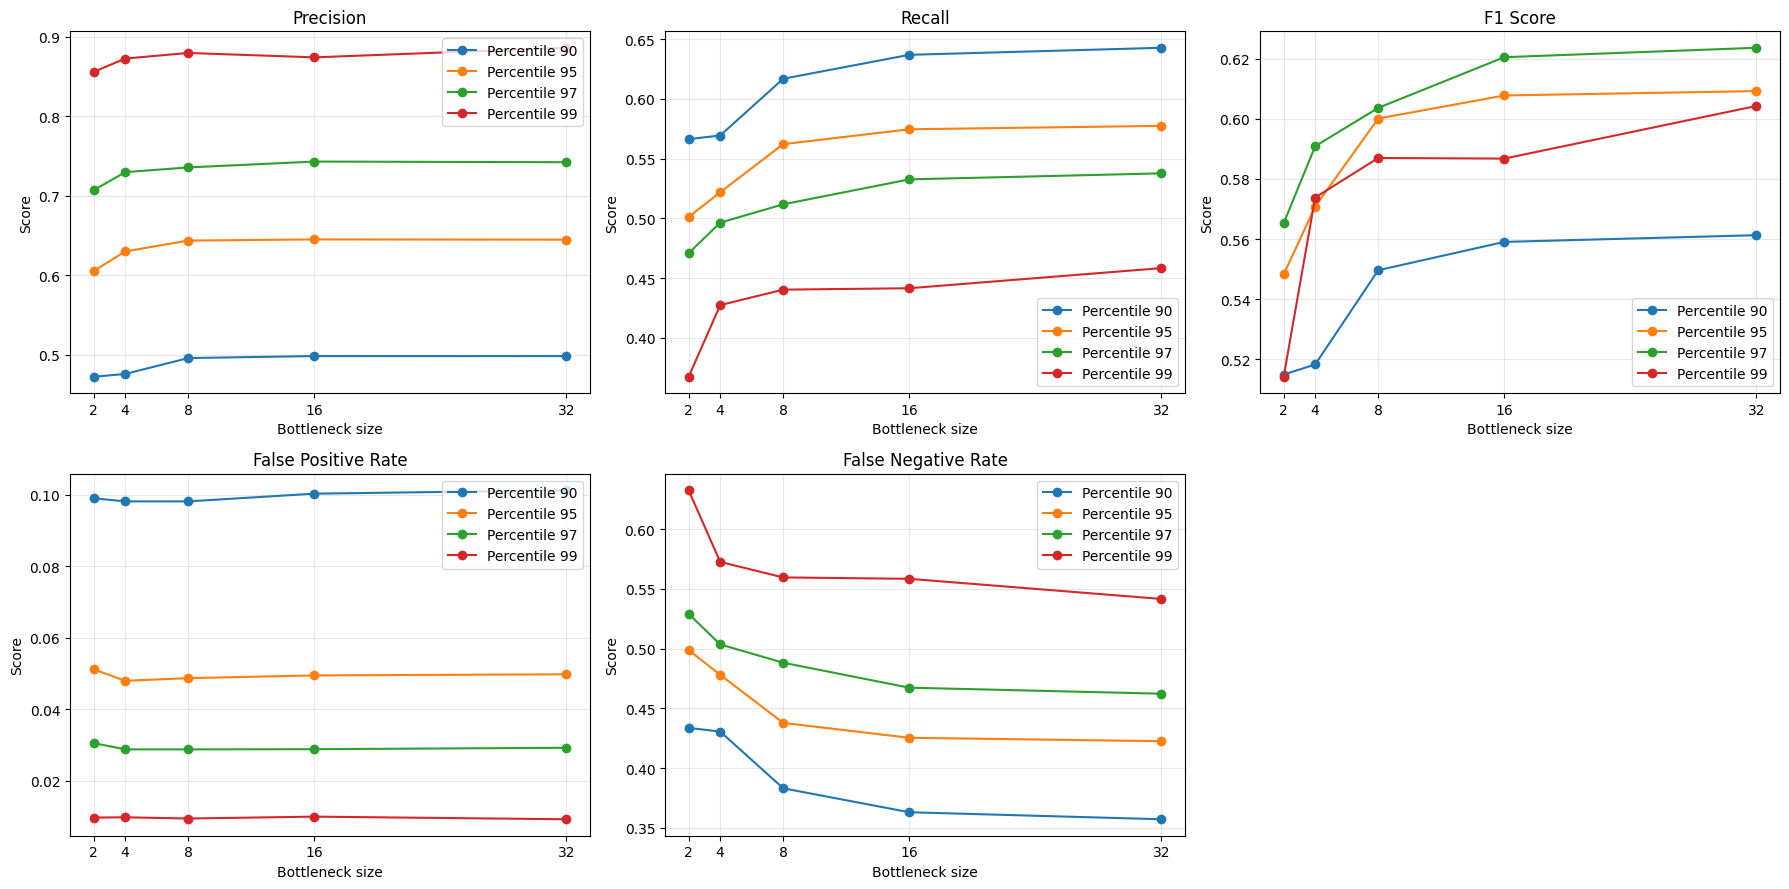

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for axis, metric, title in zip(
    axes[:5],
    ["precision", "recall", "f1", "fpr", "fnr"],
    ["Precision", "Recall", "F1 Score", "False Positive Rate", "False Negative Rate"],
):
    for percentile in threshold_percentiles:
        subset = ae_results_df[
            ae_results_df["threshold_percentile"] == percentile
        ].sort_values("bottleneck_size")
        axis.plot(
            subset["bottleneck_size"],
            subset[metric],
            marker="o",
            label=f"Percentile {percentile}",
        )
    axis.set(title=title, xlabel="Bottleneck size", ylabel="Score")
    axis.set_xticks(bottleneck_sizes)
    axis.grid(alpha=0.3)
    axis.legend()

axes[5].axis("off")
plt.tight_layout()
plt.show()